In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../results/sweep_alpha/aggregated_summary.csv")
df.head()

,alpha,seed,T,d,r,beta,lambda_reg,covariance_type,rho,length_scale,...,n_train,n_population,train_loss,population_risk,bayes_population_risk,empirical_bayes_risk,weight_norm,trace_s,top_eigenvalue,R1
0,0.5,0,4,50,50,1.0,0.0,identity,NaN,NaN,...,1250,5000,1.252321,1.254837,1.0,1.004255,2.728060,2.728060,0.676908,0.248128
1,1.0,0,4,50,50,1.0,0.0,identity,NaN,NaN,...,2500,5000,1.248257,1.248964,1.0,0.996308,1.763231,1.763231,0.567859,0.322056
2,2.0,0,4,50,50,1.0,0.0,identity,NaN,NaN,...,5000,5000,1.252264,1.250181,1.0,0.997268,0.724054,0.724054,0.265579,0.366794
3,3.0,0,4,50,50,1.0,0.0,identity,NaN,NaN,...,7500,5000,1.247036,1.247835,1.0,0.998530,0.487936,0.487936,0.138370,0.283581
4,5.0,0,4,50,50,1.0,0.0,identity,NaN,NaN,...,12500,5000,1.248297,1.252404,1.0,0.998870,0.269074,0.269074,0.087507,0.325215


In [11]:
df["generalization_gap"] = df["population_risk"] - df["train_loss"]
df["excess_population_risk"] = df["population_risk"] - df["bayes_population_risk"]
df["excess_population_risk_emp"] = df["population_risk"] - df["empirical_bayes_risk"]

In [12]:
swept_hparams = [
    "alpha",
    "beta",
    "lambda_reg",
    "T",
    "d",
    "covariance_type",
    "rho",
]

In [13]:
metrics_to_plot = [
    "train_loss",
    "population_risk",
    "bayes_population_risk",
    "excess_population_risk",
    "generalization_gap",
    "trace_s",
    "top_eigenvalue",
    "R1",
]

In [14]:
def plot_marginal_effect(
    df: pd.DataFrame,
    vary: str,
    metrics: list[str],
    exclude_missing: bool = True,
    figsize_per_row=(6, 4),
):
    """
    Plot the marginal effect of one hyperparameter by averaging metrics
    over all other hyperparameters.

    Parameters
    df : pd.DataFrame
        Input dataframe
    vary : str
        Column name of the hyperparameter to vary.
    metrics : list[str]
        Metric columns to plot.
    exclude_missing : bool
        If True, drop rows where the varied hyperparameter is missing.
    """
    subset = df.copy()

    if exclude_missing:
        subset = subset[subset[vary].notna()]

    if subset.empty:
        print(f"No data available for varying {vary}.")
        return

    n_metrics = len(metrics)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_row[0] * ncols, figsize_per_row[1] * nrows),
        squeeze=False,
    )
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        grouped = (
            subset.groupby(vary)[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        grouped["sem"] = grouped["std"] / np.sqrt(grouped["count"])

        # Try numeric sorting if possible
        try:
            grouped = grouped.sort_values(by=vary)
        except Exception:
            pass

        x = grouped[vary]
        y = grouped["mean"]
        yerr = grouped["sem"]

        ax = axes[i]
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
        ax.set_xlabel(vary)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs {vary} (averaged)")
        ax.grid(True, alpha=0.3)

    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Marginal effect of {vary}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_vary_one_hparam(
    df: pd.DataFrame,
    vary: str,
    fixed: dict,
    metrics: list[str],
    sort_x: bool = True,
    figsize_per_row=(6, 4),
):
    """
    Plot several metrics while varying one hyperparameter and fixing the others.

    Parameters
        df aggregated df
        vary : str : hyperparameter to vary on the x-axis.
        fixed : dict : dictionary of fixed hyperparameters, e.g. {"T": 4, "d": 50, "beta": 10.0, "lambda_reg": 0.1, "covariance_type": "toeplitz", "alpha": 2.0}
        metrics : list[str] : list of metric columns to plot.
        sort_x : bool : whether to sort by the x-axis values.
    """
    subset = df.copy()

    for key, value in fixed.items():
        subset = subset[subset[key] == value]

    if subset.empty:
        print("No rows match the requested fixed hyperparameters.")
        return

    # keep only cols we need
    cols = [vary] + metrics
    subset = subset[cols].dropna()

    if subset.empty:
        print("Subset is empty after dropping missing values.")
        return

    # if multiple rows remain for the same x value --> avg them
    grouped = subset.groupby(vary, as_index=False).mean(numeric_only=True)

    if sort_x:
        grouped = grouped.sort_values(by=vary)

    n_metrics = len(metrics)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_row[0] * ncols, figsize_per_row[1] * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    x = grouped[vary]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        ax.plot(x, grouped[metric], marker="o")
        ax.set_xlabel(vary)
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} vs {vary}")
        ax.grid(True, alpha=0.3)

    # remove unused subplots
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    fixed_str = ", ".join(f"{k}={v}" for k, v in fixed.items())
    fig.suptitle(f"Varying {vary} // Fixed: {fixed_str}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

### 1. Vary rho

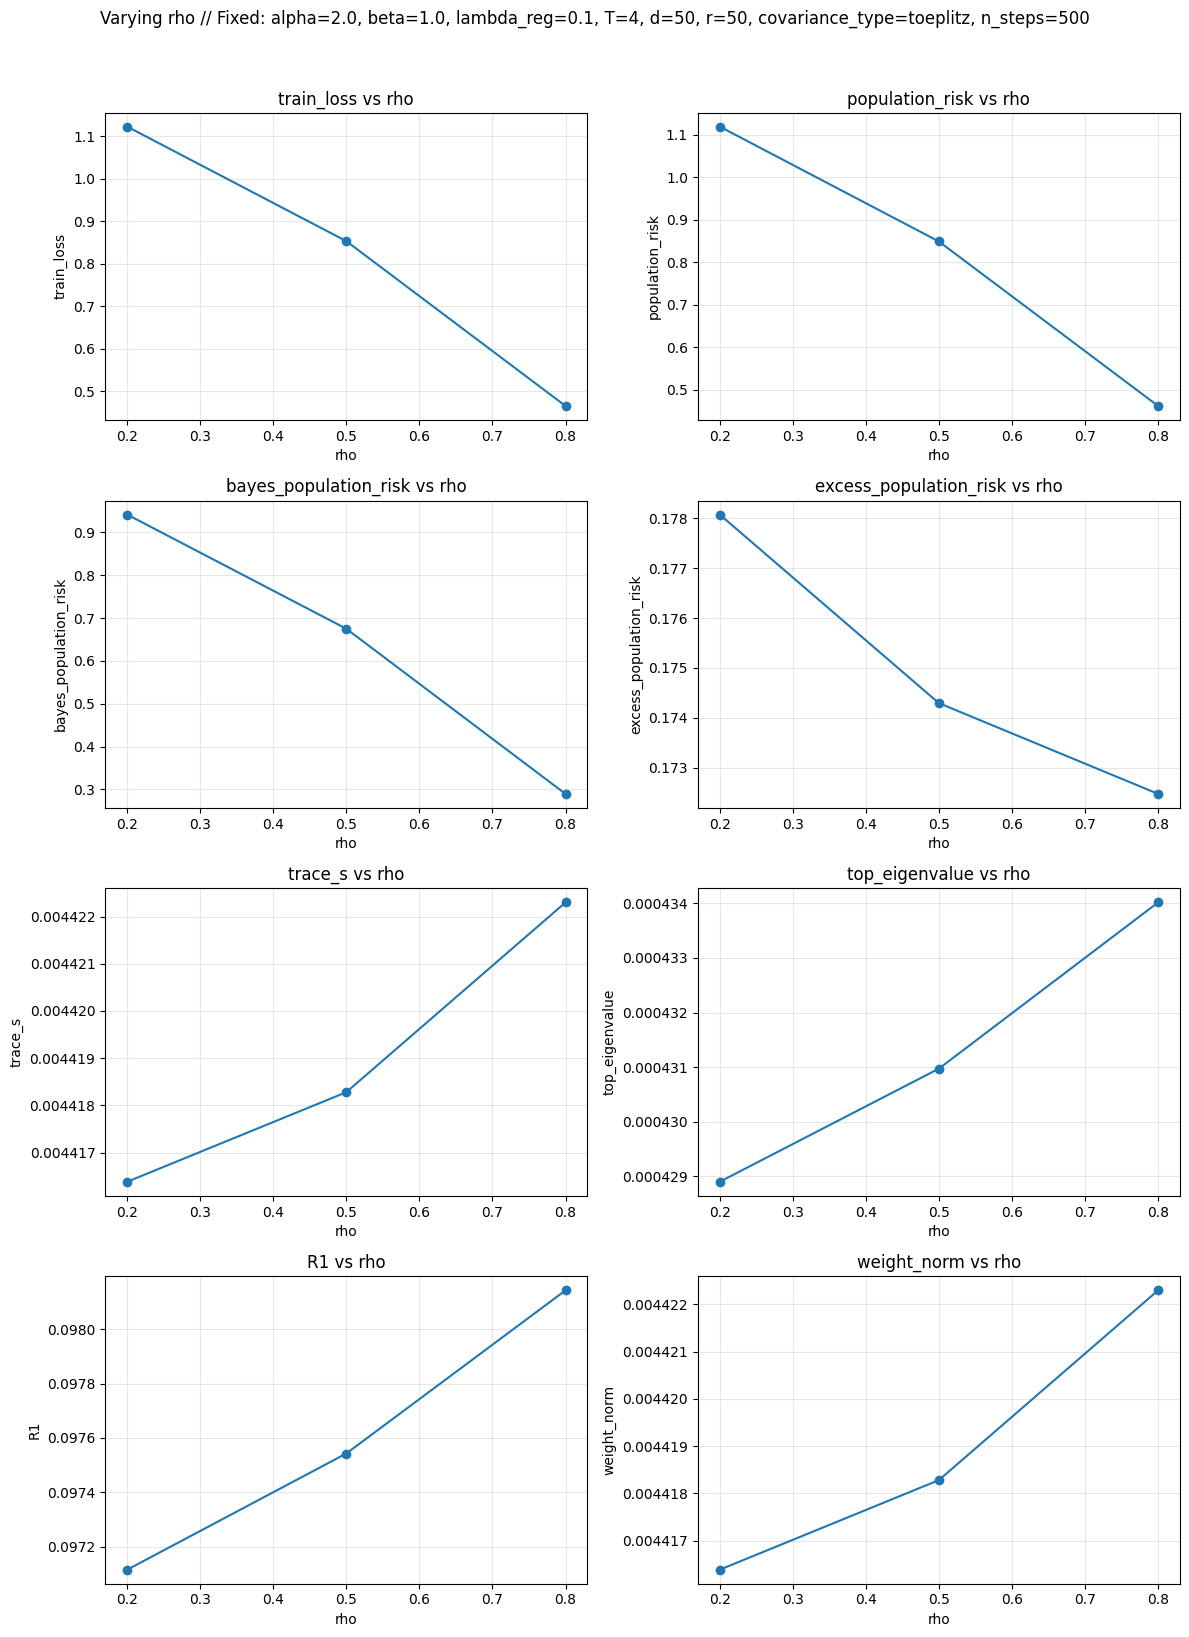

In [18]:
fixed = {
    "alpha": 2.0,
    "beta": 1.0,
    "lambda_reg": 0.1,
    "T": 4,
    "d": 50,
    "r": 50,
    "covariance_type": "toeplitz",
    "n_steps": 500,
}

plot_vary_one_hparam(
    df=df,
    vary="rho",
    fixed=fixed,
    metrics=[
        "train_loss",
        "population_risk",
        "bayes_population_risk",
        "excess_population_risk",
        "trace_s",
        "top_eigenvalue",
        "R1",
        "weight_norm",
    ],
)

In [ ]:
plot_marginal_effect(
    df=df,
    vary="rho",
    metrics=metrics_to_plot,
)

NameError: name 'df' is not defined

: 

: 

### 2. Vary lambda

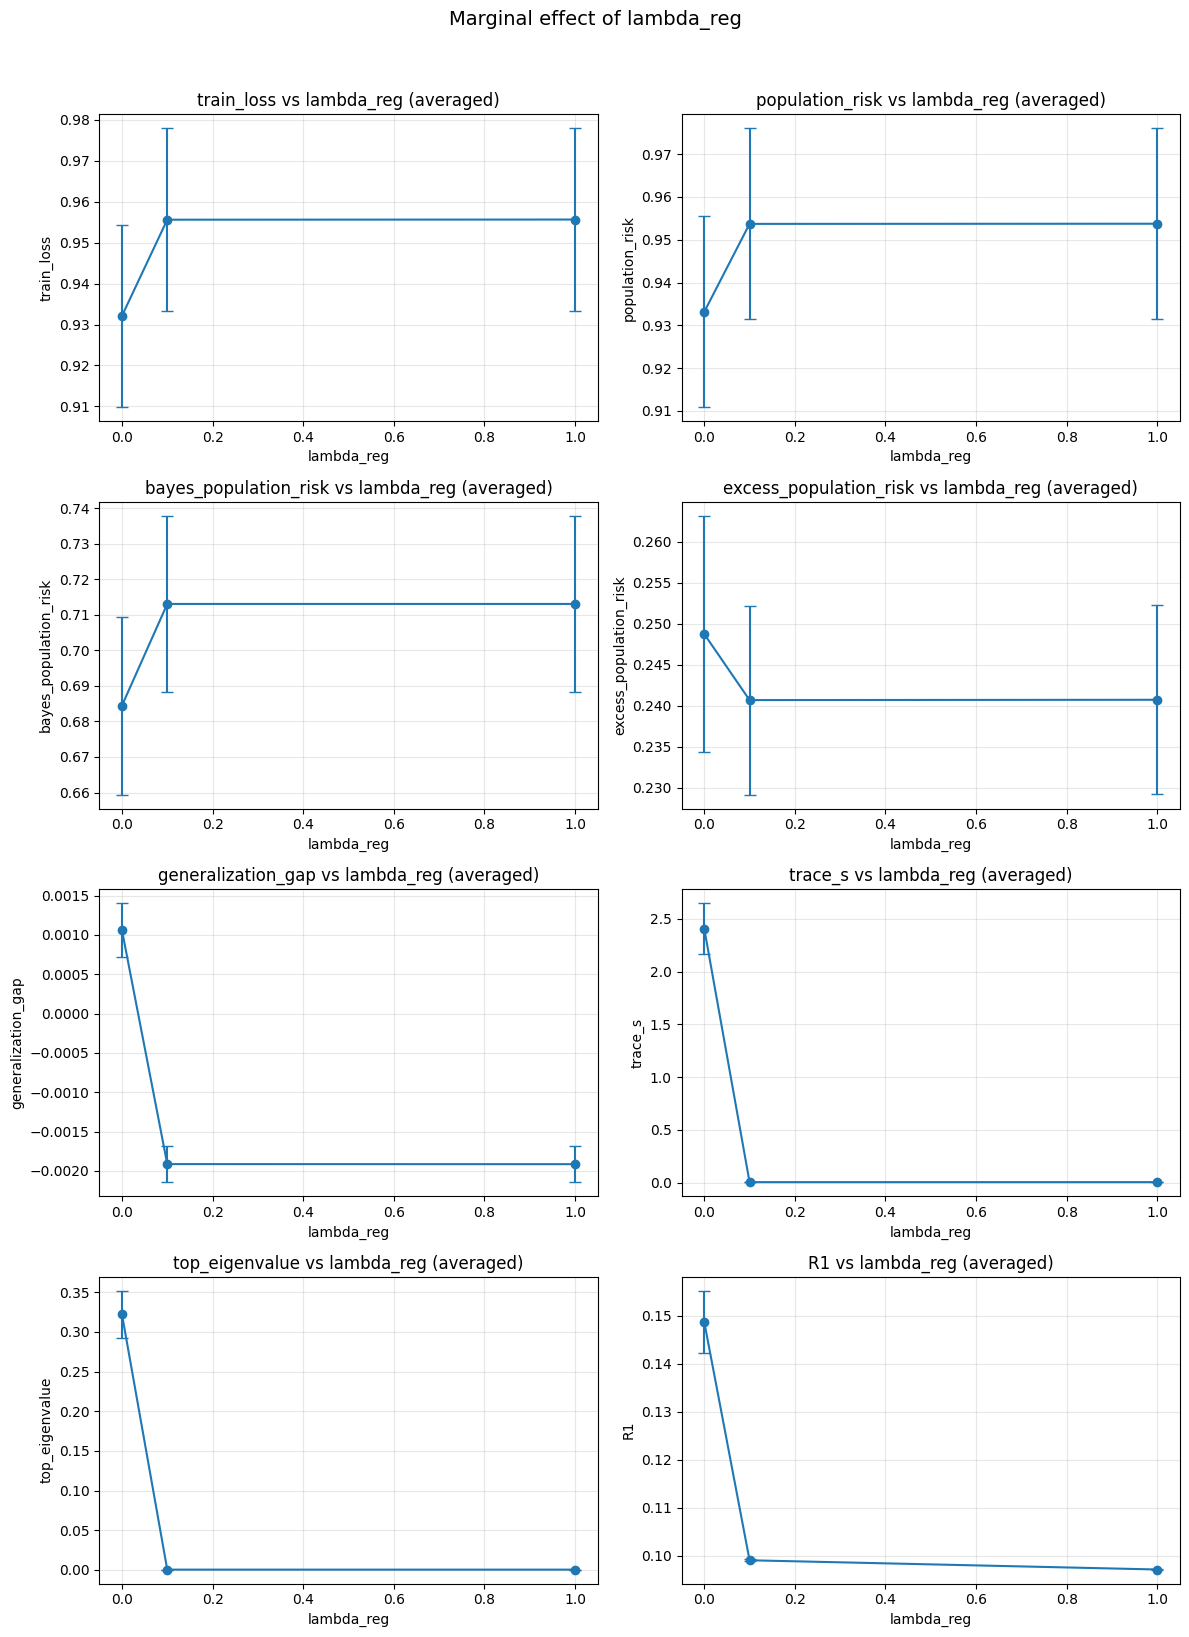

In [17]:
plot_marginal_effect(
    df=df,
    vary="lambda_reg",
    metrics=metrics_to_plot,
)

### 3. Vary beta

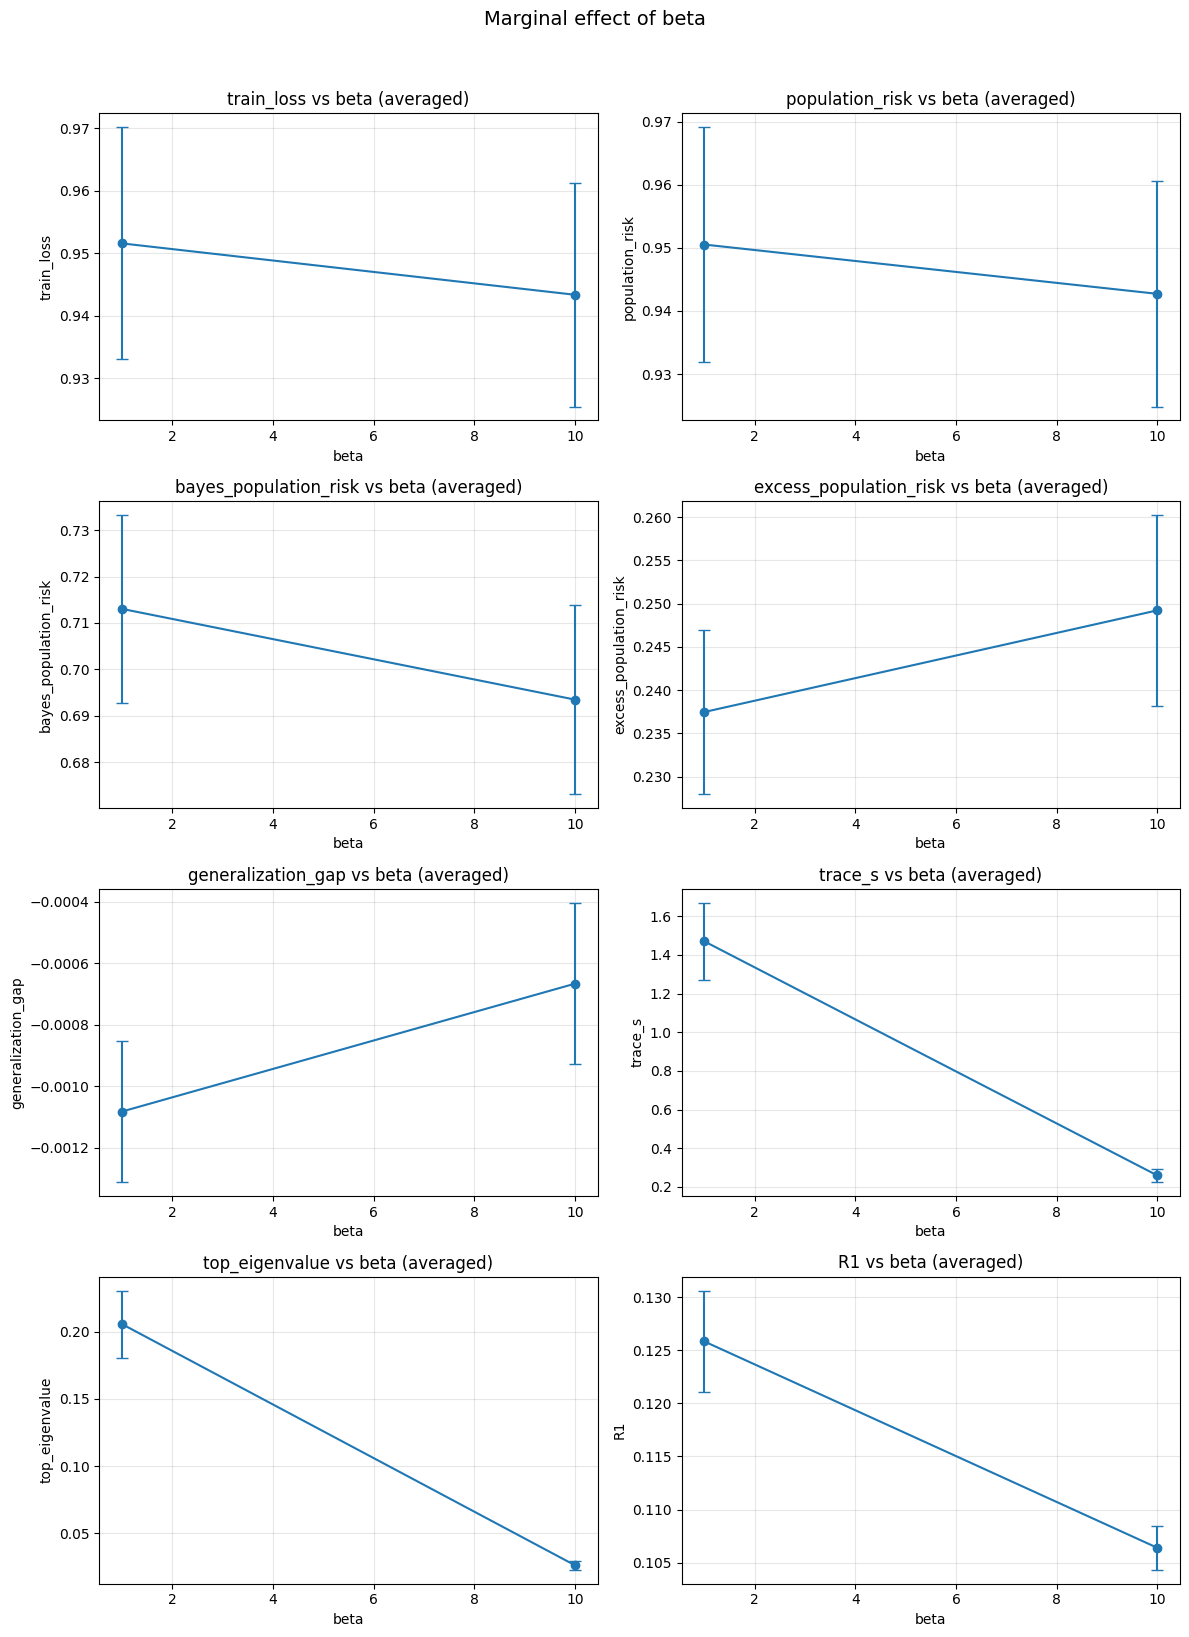

In [20]:
plot_marginal_effect(
    df=df,
    vary="beta",
    metrics=metrics_to_plot,
)

## 4. Vary alpha

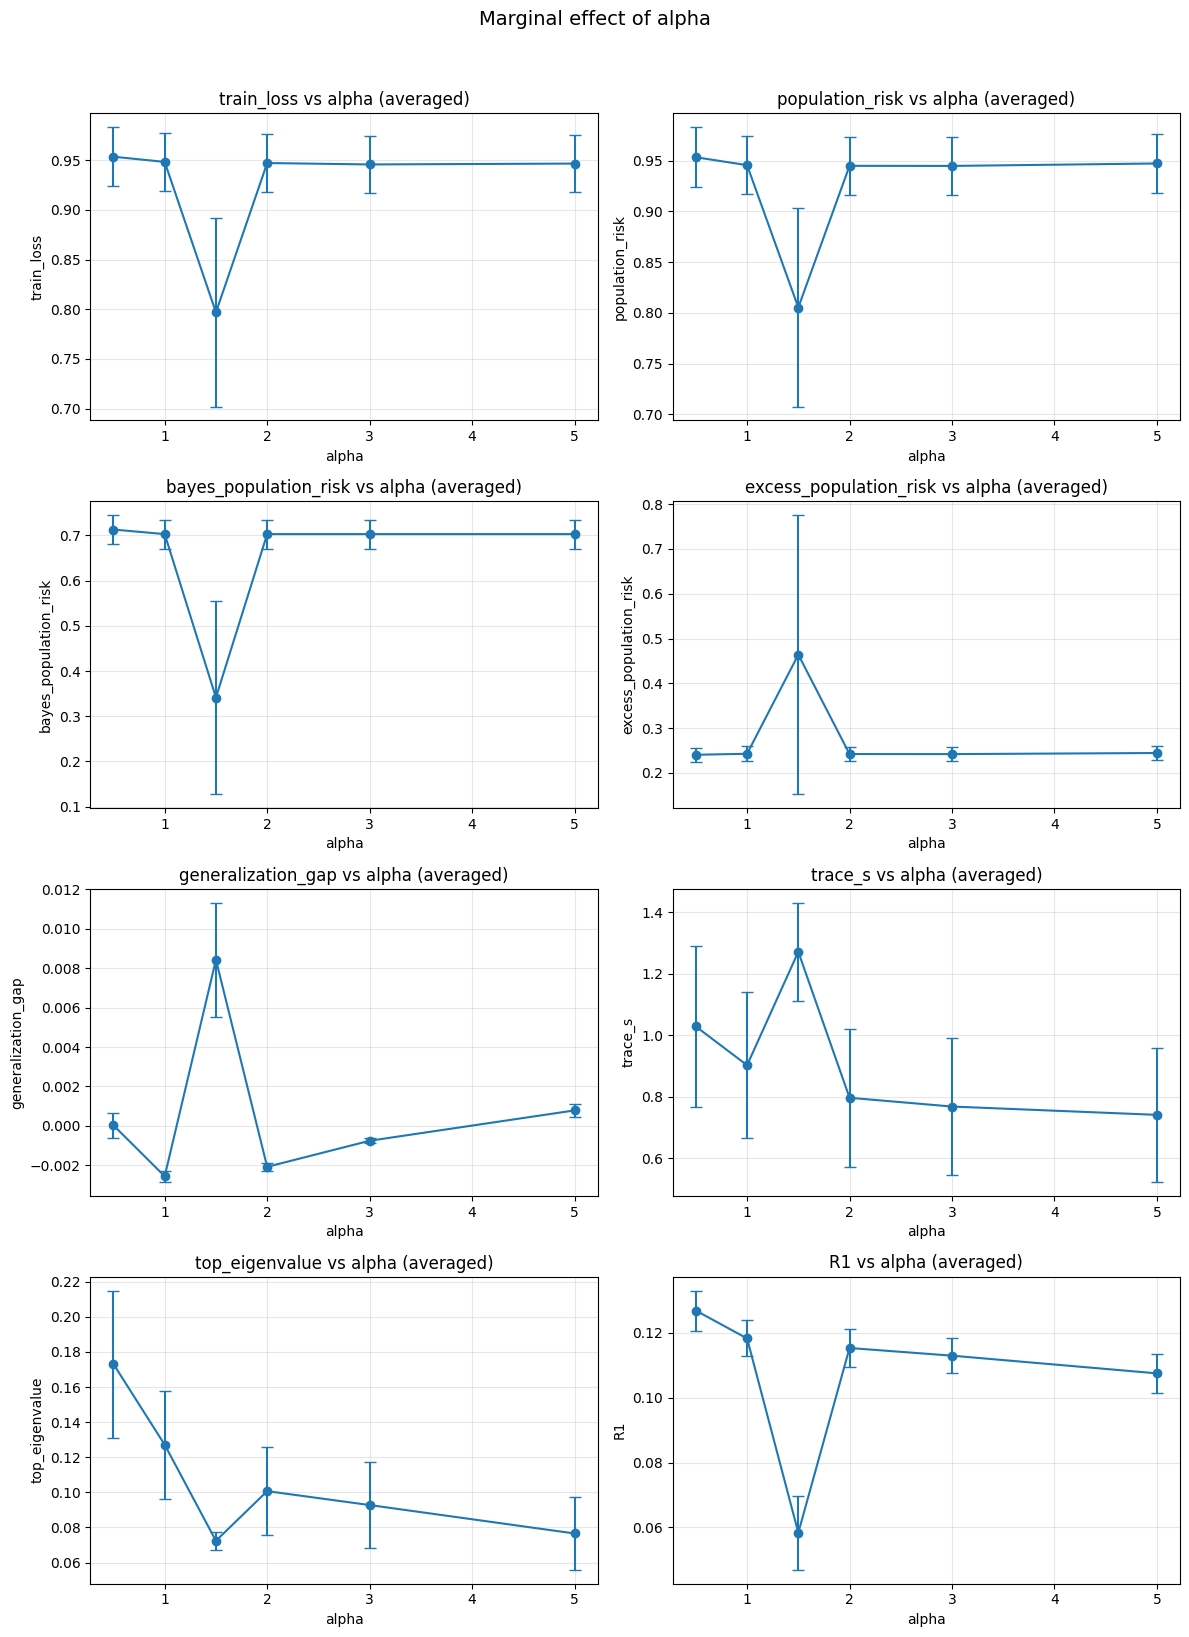

In [21]:
plot_marginal_effect(
    df=df,
    vary="alpha",
    metrics=metrics_to_plot,
)

### Vary T

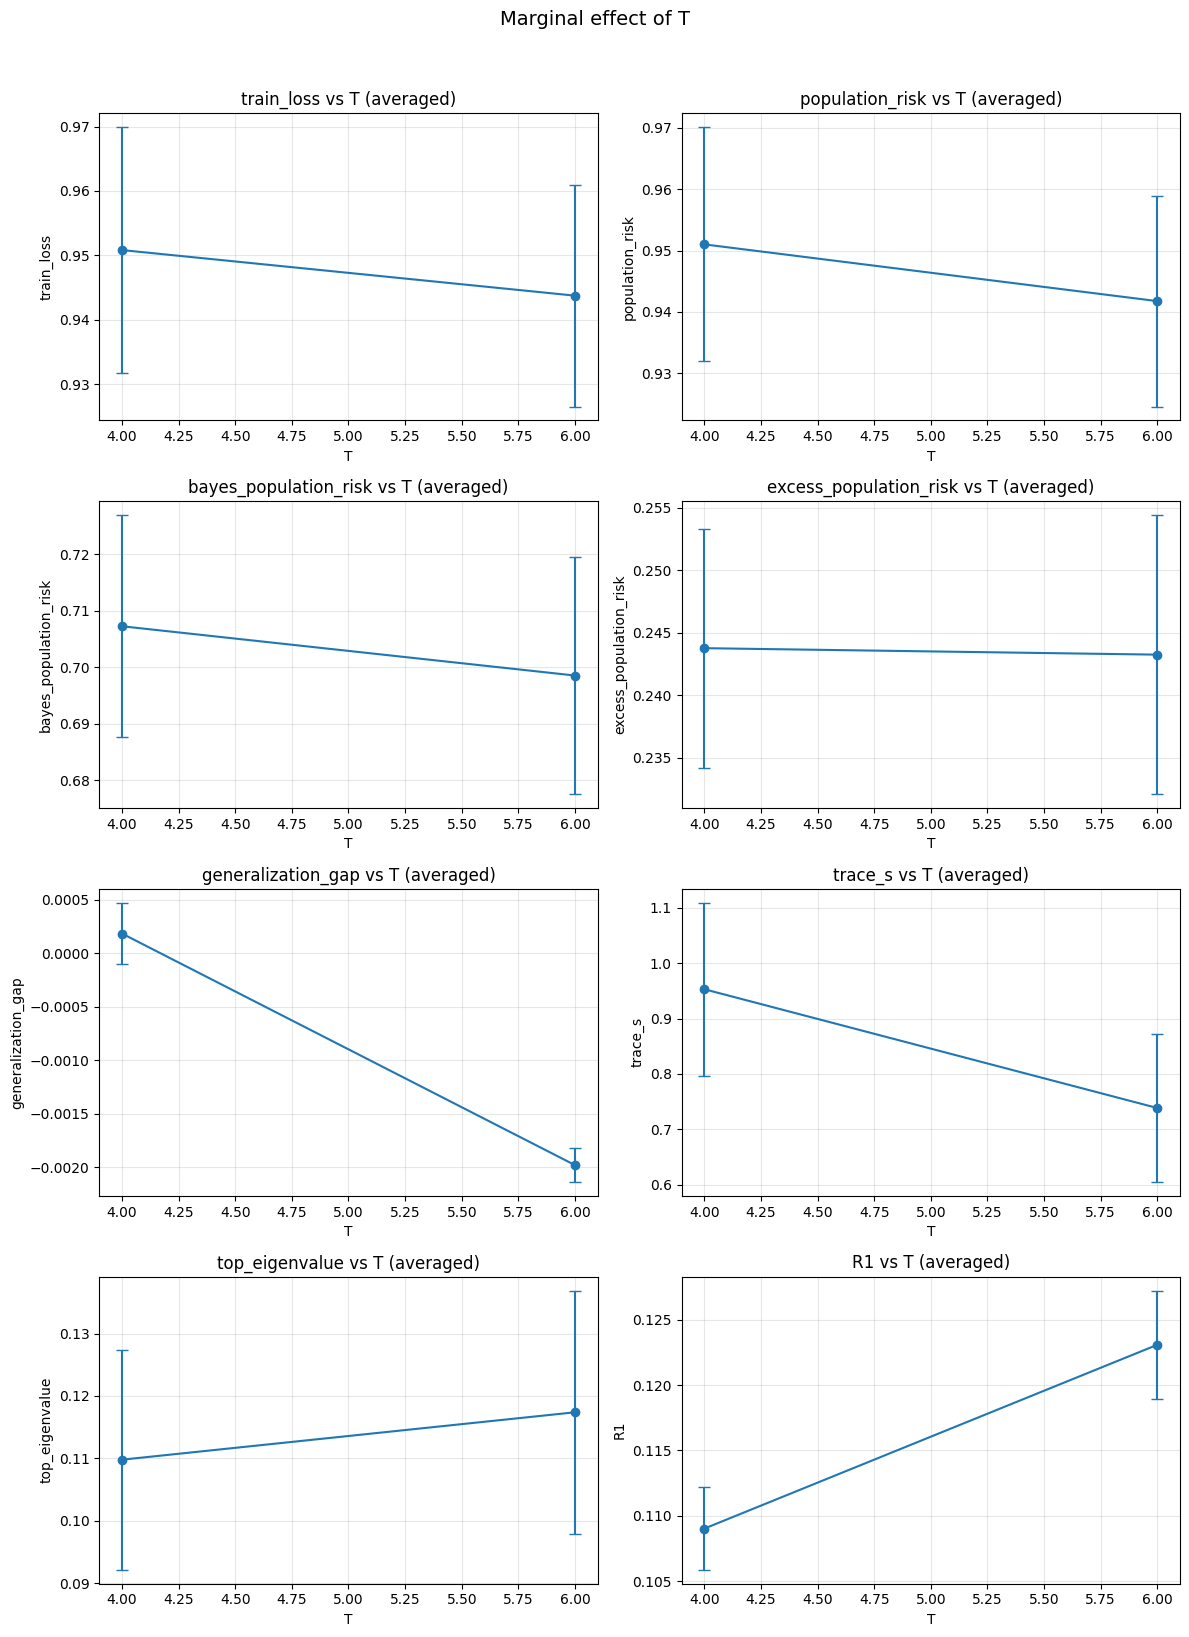

In [22]:
plot_marginal_effect(
    df=df,
    vary="T",
    metrics=metrics_to_plot,
)

### Vary d

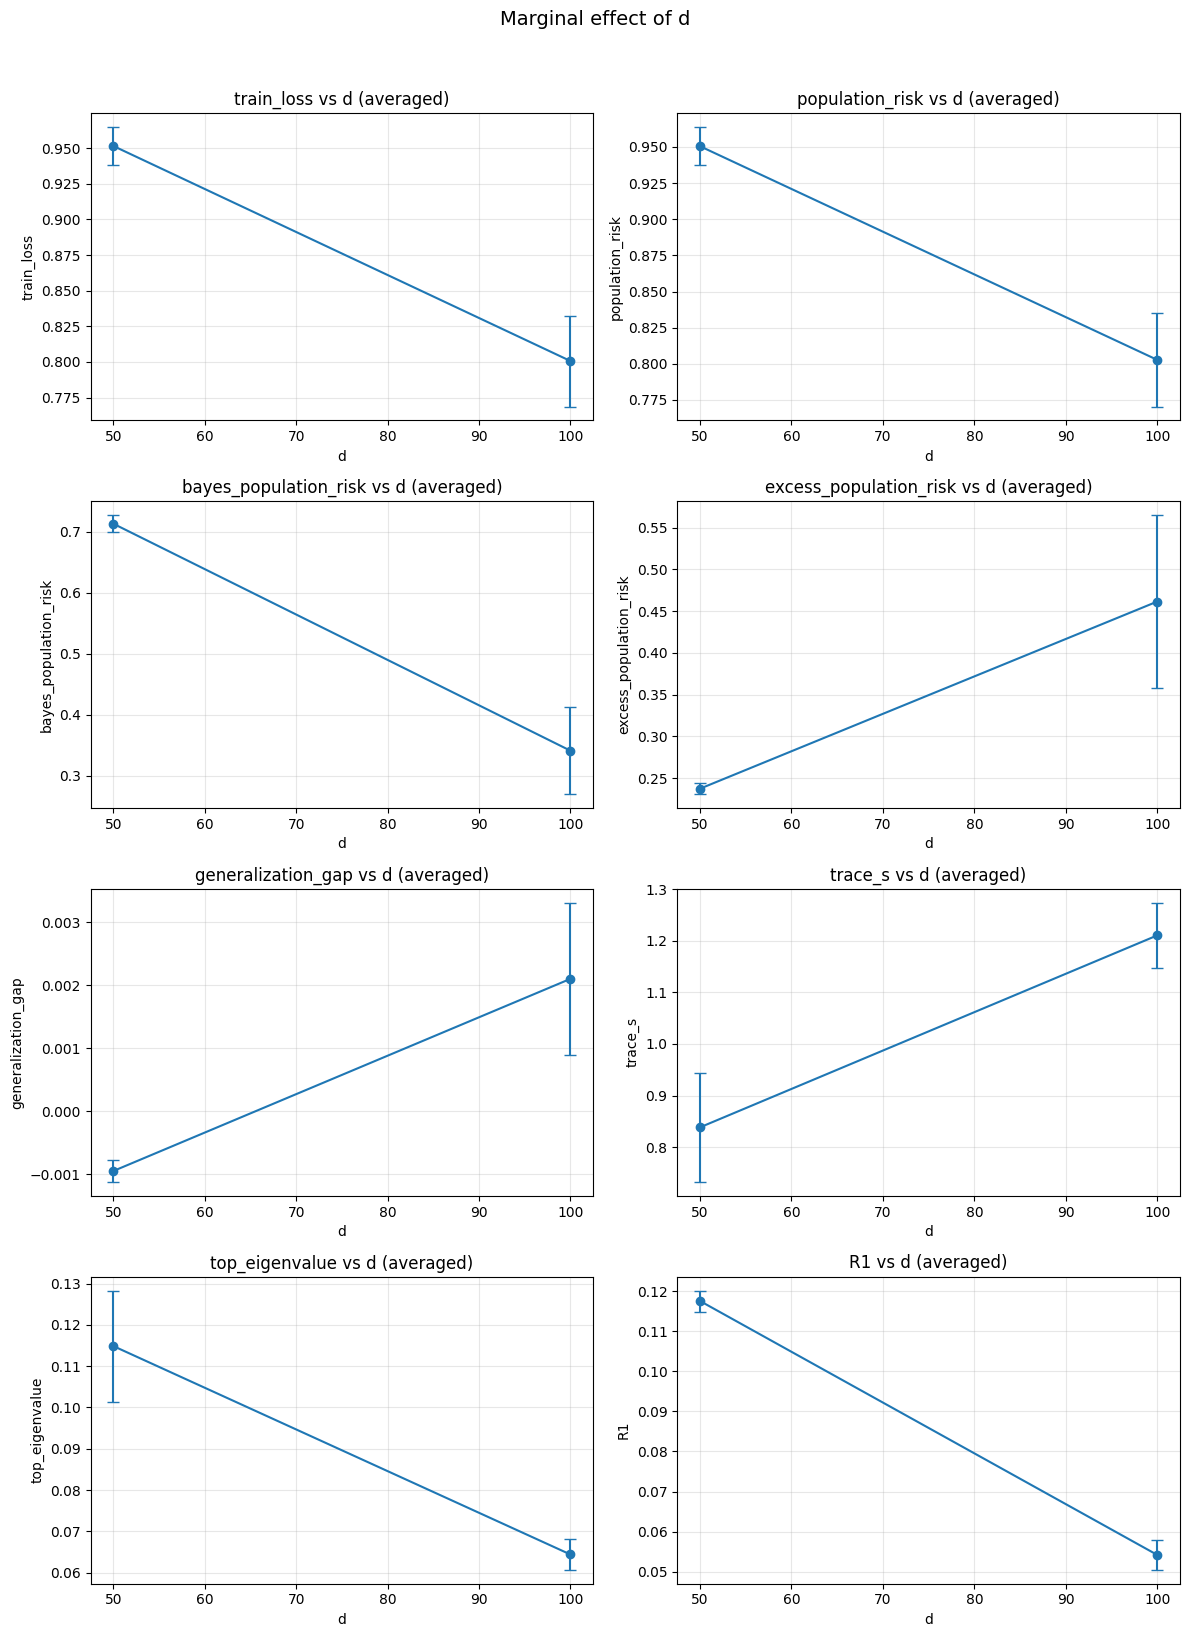

In [23]:
plot_marginal_effect(
    df=df,
    vary="d",
    metrics=metrics_to_plot,
)

### Vary covariance type

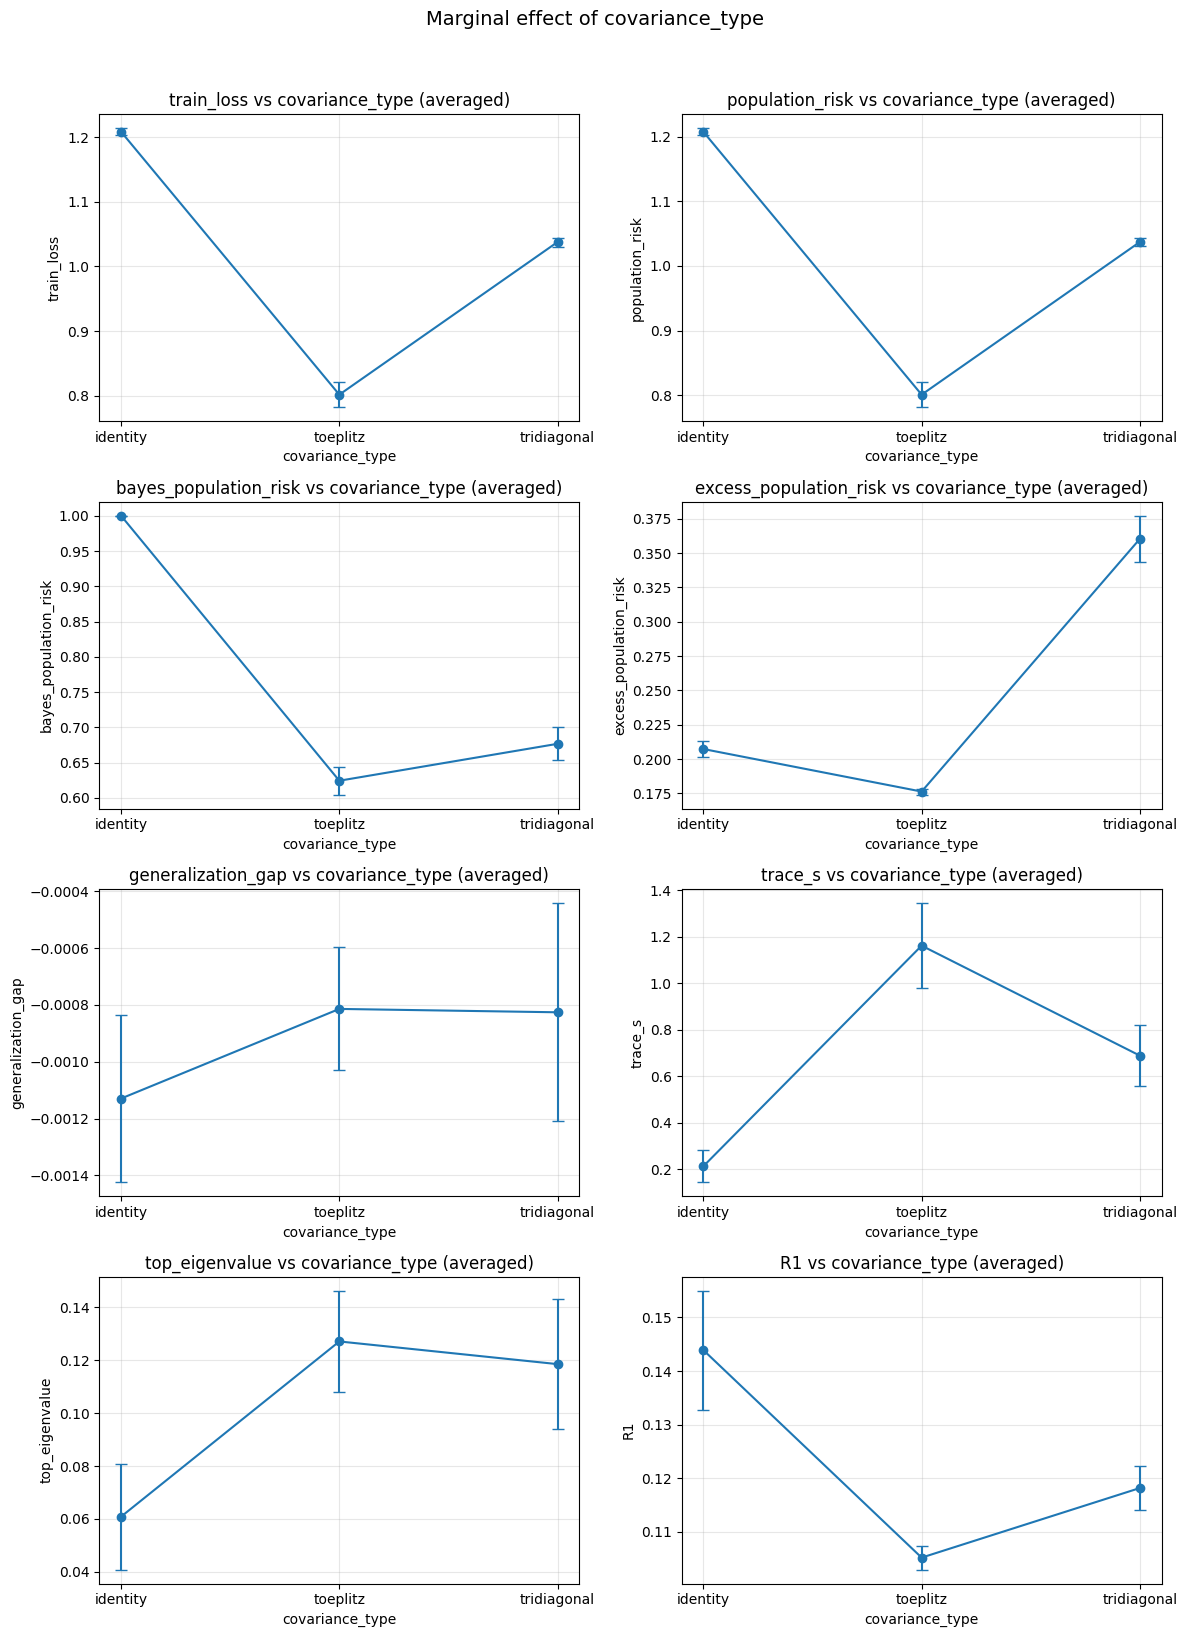

In [25]:
plot_marginal_effect(
    df=df,
    vary="covariance_type",
    metrics=metrics_to_plot,
)